# Day 2: Database SQL Visualization

In [37]:
import pandas as pd
import sqlite3                          # create, connect, and work with SQLite databases
import matplotlib.pyplot as plt         # creating graphs and charts
import warnings                         # control warning messages generated by programs
warnings.filterwarnings('ignore')       # Tells Python to hide all warning messages
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")
print(f"matplotlib version:{plt.matplotlib.__version__}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0
matplotlib version:3.10.0


In [38]:
from google.colab import drive          # connects  Google Drive storage with Colab
drive.mount('/content/drive')           # After mounting, Colab can access files stored in your Drive

df = pd.read_csv("/content/student_performance.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print("\nFirst 3 rows")
df.head(3)

Dataset loaded:30 students,13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


Step A: Connect to (or create) a database file

In [40]:

conn = sqlite3.connect('college.db')
# Connect to SQLite database
# If 'college.db' does not exist, SQLite will create it automatically

cursor = conn.cursor()
# Create a cursor object
# Cursor is used to execute SQL queries

df.to_sql(                # Store Pandas DataFrame into SQL table
    'students',           #tablename
    conn,                 #creating this table inside college.db
    if_exists='replace',  #if table already exists, replace it
    index=False           # Do not store DataFrame index as a column
)
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
# fetchone() returns tuple like: (100,)
# [0] extracts the value 100

print(f"Database 'college.db' created successfully")
print(f"Table student has {count} students")


Database 'college.db' created successfully
Table student has 30 students


**PRAGMA table_info(students)** is a SQLite command.

Returns information about all columns in the students table.

In [41]:
cursor.execute("PRAGMA table_info(students)")         # table_info shows the structure of the table
columns_info = cursor.fetchall()                      # fetchall() retrieves all result rows

print("Table Structure of 'students'")
print(f"{'column Name':<25}{'Data Types':<12}")       # <25 means reserve 25 spaces and align left
print("-"*38)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")

Table Structure of 'students'
column Name              Data Types  
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


# Basic Syntax of SQL

```
SELECT column1, column2
FROM table_name
WHERE condition
GROUP BY column
HAVING group_condition
ORDER BY column DESC
LIMIT 10;
```



In [42]:
def run_query(sql,description=""):    # sql query, optional text label
   """
  Runs a SQL query and returns result as a Pandas DataFrame
  Parameters:
  -------------
  sql          :str - SQL query string to execute
  description  :str - A label to print above the results
  Returns:
  ----------
   Pandas DataFrame containing the query results
  """
   if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
   result=pd.read_sql_query(sql, conn)   # Pandas sends SQL query to SQLite database,executes, Converts into DataFrame
   print(result.to_string(index=False))  # clean text format
   return result

**1. First 10 students** (SELECT + LIMIT)

In [43]:
query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10
"""
result = run_query(query1,"Query 1: First 10 students")


Query 1: First 10 students
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


**2. Top 5 Math Scorers** (ORDER BY DESC + LIMIT)

In [44]:
query2 = """
SELECT name,department, math_score
FROM students
ORDER BY math_score DESC
LIMIT 5
"""
result2=run_query(query2,"Query2: Top 5 Math Scorers ")


Query2: Top 5 Math Scorers 
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


**3. Computer Science Students** (WHERE filter + ORDER BY DESC)

In [45]:
query3=""" SELECT name, math_score, science_score, programming_score, attendance_percentage
FROM students
WHERE department ='Computer Science'
ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query3:Computer Science Students (WHERE filter)")
print(f"\nTotal CS students found: {len(result3)}")


Query3:Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79 

**4. High Attendance(>90%) Excluding Civil Dept**

In [46]:
query4="""
SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage>90
AND department!="civil"
ORDER BY attendance_percentage DESC
"""
result4 = run_query(query4,"Query 4: High Attendance(>90%) Excluding Civil Dept")


Query 4: High Attendance(>90%) Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


**5. Department Summary**

In [47]:
query5="""
SELECT
department,
COUNT(*) AS num_students,
ROUND(AVG(math_score),2) AS avg_math_score,
ROUND(AVG(science_score),2) AS avg_science_score,
ROUND(AVG(programming_score),2) AS avg_programming_score,
ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
FROM students
GROUP BY department
ORDER BY avg_math_score DESC
"""
result5 = run_query(query5,"Query 5: Department Summary ")



Query 5: Department Summary 
      department  num_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science            13           85.62              84.46                  89.23                      90.69
      Mechanical             6           71.00              76.50                  49.33                      83.50
     Electronics             6           71.00              74.17                  61.50                      80.33
           Civil             5           63.40              66.60                  40.60                      74.60


**6. Department Summary** (HAVING filter)

In [48]:
query6="""
  SELECT
  department,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math_score
  FROM students
  GROUP BY department
  HAVING AVG(math_score)>70
  ORDER BY avg_math_score DESC
"""
result6=run_query(query6,"Query6: Department Summary (HAVING filter)")



Query6: Department Summary (HAVING filter)
      department  num_students  avg_math_score
Computer Science            13           85.62
      Mechanical             6           71.00
     Electronics             6           71.00


**7. Gender Based Analysis**

In [49]:
query7="""
  SELECT
  gender,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math_score,
  ROUND(AVG(programming_score),2) AS avg_programming,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
  FROM students
  GROUP BY gender
"""
result7=run_query(query7,"Query7: Gender Based Analysis")




Query7: Gender Based Analysis
gender  num_students  avg_math_score  avg_programming  avg_attendance_percentage
Female            15           78.47             70.2                      88.53
  Male            15           73.67             65.0                      80.47


**8. Top 10 Students by Total Score**

In [50]:
query8="""
  SELECT
  name,
  department,
  math_score+science_score+programming_score AS total_score
  FROM students
  ORDER BY total_score DESC
  LIMIT 10
"""
result8=run_query(query8,"Query8: Top 10 Students by Total Score")


Query8: Top 10 Students by Total Score
          name       department  total_score
    Ananya Das Computer Science          281
   Tanvi Mehta Computer Science          279
Akanksha Yadav Computer Science          278
    Arjun Nair Computer Science          275
   Divya Singh Computer Science          272
Swati Kulkarni Computer Science          269
    Suresh Rao Computer Science          257
     Amit Bose Computer Science          257
  Aarav Sharma Computer Science          254
 Gaurav Shukla Computer Science          250




*   like creating a table (department)
*   A Python dictionary
*   Each key becomes a column
*   Each list becomes rows

In [51]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established':[1985,1988,1972,1965],
    'intake': [60,60,60,60]
}


In [52]:
dept_df=pd.DataFrame(dept_data)                                      # converts dictionary → DataFrame
dept_df.to_sql('departments',conn,if_exists='replace',index=False)   # create department table
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={                               # lookup table - full department names -> short codes
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)   #O verwrites existing students table

Created 'departments' table:
dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics  Dr.Reddy         1988      60
       ME       Mechanical  Dr.Patel         1972      60
       CE            Civil  Dr.Kumar         1965      60


30

Joins (Inner)

In [53]:
query_join = """
  SELECT
    s.name,
    s.math_score,
    d.dept_name,
    d.hod_name,
    d.established
  FROM students AS s
  INNER JOIN departments AS d
  ON s.dept_code = d.dept_code ORDER BY s.math_score DESC
  LIMIT 8
  """
result_join = run_query(query_join, "Query: Student Details with Department Information")


Query: Student Details with Department Information
          name  math_score        dept_name  hod_name  established
    Ananya Das          95 Computer Science Dr.Sharma         1985
   Tanvi Mehta          93 Computer Science Dr.Sharma         1985
    Arjun Nair          92 Computer Science Dr.Sharma         1985
Akanksha Yadav          91 Computer Science Dr.Sharma         1985
Swati Kulkarni          90 Computer Science Dr.Sharma         1985
   Divya Singh          88 Computer Science Dr.Sharma         1985
  Ritu Agarwal          87      Electronics  Dr.Reddy         1988
     Amit Bose          86 Computer Science Dr.Sharma         1985


# UNIT 3: Data Visualization with Matplotlib

Now we turn our SQL results into professional charts.

## The Pattern we follow:

SQL Query → `pd.read_sql_query()` → DataFrame → Matplotlib chart

---

## Matplotlib Anatomy

```python
fig, ax = plt.subplots(figsize=(width, height))

ax.bar(x, y)

ax.set_title('...')

ax.set_xlabel('...')

ax.set_ylabel('...')

plt.tight_layout()

plt.show()

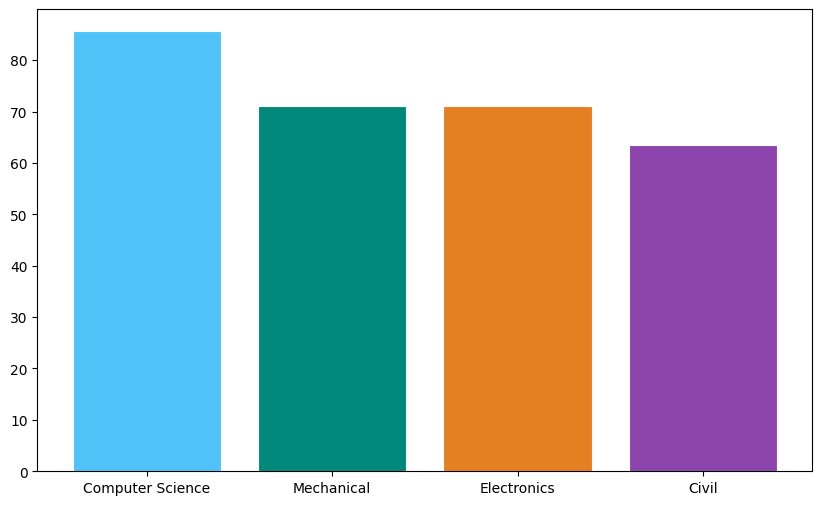

In [54]:
# Step 1: Get data using SQL

chart1_sql = """
SELECT department,
ROUND (AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""                                         # two columns: 'department' and 'avg_math'

chart1_data = pd.read_sql_query(chart1_sql, conn)

# Step 2: Create the bar chart

fig, ax = plt.subplots(figsize=(10, 6))     # fig = entire canvas(blank sheet of paper)
                                            # ax = actual plot area (bars/lines are drawn)
                                            # 10 inches wide, 6 inches tall
bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
bars = ax.bar(

  chart1_data['department'], # x-axis categories (dept)
  chart1_data['avg_math'],   # y-axis (heights of bars)
  color=bar_colors,          # Each bar gets a color from list
  edgecolor='white',         # white border around
  linewidth=0.8              #thickness of the border
)


**Practice Questions**

Question 1: Write a SQL query to find the average programming score for female students only.

In [55]:
query1 = """
SELECT
ROUND(AVG(programming_score),2) AS avg_programming_score
FROM students
WHERE gender='Female'
"""
result1= run_query(query1,"Query 1: Average Programming Score of Female Students")


Query 1: Average Programming Score of Female Students
 avg_programming_score
                  70.2


Question 2: What is the difference between WHERE and HAVING? Write one example of each using the students table.

**WHERE**
-Filters rows before grouping

-Used without GROUP BY

-Cannot use aggregate functions
Example:
```
query2_where = """
SELECT
    name,
    math_score
FROM students
WHERE math_score > 80
"""

result2_where = run_query(
    query2_where,
    "Query 2A: WHERE Example"
)
```
**HAVING**
-Filters groups after grouping

-Mostly used with GROUP BY

-directly	Can use aggregate functions
Example:

```
query2_having = """
SELECT
    department,
    ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
HAVING AVG(math_score) > 75
"""

result2_having = run_query(
    query2_having,
    "Query 2B: HAVING Example"
)
```



Question 3: Write a SQL query to find all departments where the average attendance is above 85%.

In [56]:
query2 ="""
SELECT department,
ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage)>85
"""
result3 = run_query(
    query2,
    "Query 3: Departments with Average Attendance Above 85%"
)


Query 3: Departments with Average Attendance Above 85%
      department  avg_attendance
Computer Science           90.69


Question 4: What does pd.read_sql_query() return? What two arguments does it require?

pd.read_sql_query() returns a dataframe

**The two arguments:**

SQL query, Database connection object

`df_sql = pd.read_sql_query(query, conn)`

Question 5: Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

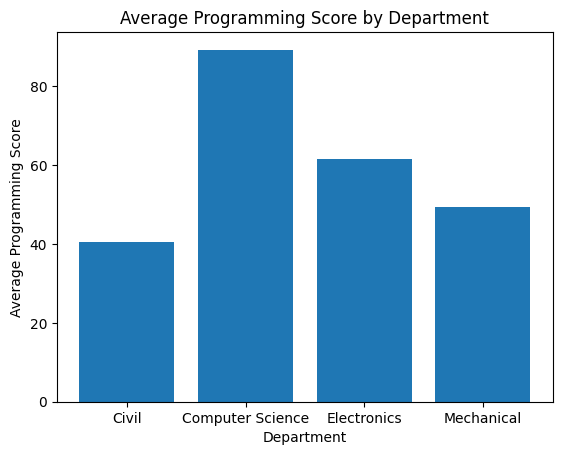

In [57]:

import matplotlib.pyplot as plt

avg_prog = df.groupby('department')['programming_score'].mean()

plt.bar(avg_prog.index, avg_prog.values)

plt.title("Average Programming Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Programming Score")

plt.show()

# Student Performance Dashboard - MINI PROJECT 2

Build a professional Student Performance Dashboard using SQL, Pandas, and Matplotlib.

You are given a SQLite database containing a table named `students` with the following columns:

* name
* department
* gender
* math_score
* science_score
* english_score
* programming_score
* attendance_percentage

---

# Tasks

Write SQL queries using `pd.read_sql_query()` to answer the following questions:

## 1. Average Math Score by Department

* Use `AVG()`
* Round values to 1 decimal place
* Sort from highest to lowest average

## 2. Student Count by Department

* Use `COUNT(*)`
* Group the results department-wise

## 3. Top 8 Students Based on Total Marks

* Total Score = math_score + science_score + english_score + programming_score
* Display student name and total score
* Sort from highest to lowest total
* Show only top 8 students

## 4. Average Attendance Percentage by Gender

* Use `AVG()`
* Round values to 1 decimal place

---

# Dashboard

Create a dashboard with 4 panels.

---

# Charts

## Panel 1

Create a vertical bar chart showing average math score by department.

* Add value labels
* Add grid lines
* Set y-axis limit to 105

## Panel 2

Create a pie chart showing the number of students in each department.

* Display percentage labels
* Use custom colors
* Add white borders

## Panel 3

Create a horizontal bar chart showing the Top 8 students based on total score.

* Display total scores inside the bars
* Place the highest scorer at the top
* Add x-axis grid lines

## Panel 4

Create a bar chart showing average attendance percentage by gender.

* Use different colors
* Display percentage labels
* Set y-axis limit to 105
* Add grid lines




In [66]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

# Panel 1 data: Avg Math by Department
query1 = """
SELECT
    department,
    ROUND(AVG(math_score),1) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
result1 = run_query(
    query1,
    "Query 1: Average Math Score by Department"
)

avg_math_df = pd.read_sql_query(query1,conn)

# Panel 2 data: Student Count by Department
query2 = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""
result2 = run_query(
    query2,
    "Query 2: Student Count by Department"
)
student_count_df=pd.read_sql_query(query2,conn)

# Panel 3 data: Top 8 Students by Total Score
query3 = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
result3 = run_query(
    query3,
    "Query 3: Top 8 Students Based on Total Marks"
)

top_students_df=pd.read_sql_query(query3,conn)
# Panel 4 data: Gender-wise Average Attendance
query4 = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),1) AS avg_attendance
FROM students
GROUP BY gender
"""

result4 = run_query(
    query4,
    "Query 4: Average Attendance Percentage by Gender"
)

attendance_df= pd.read_sql_query(query4,conn)



Query 1: Average Math Score by Department
      department  avg_math
Computer Science      85.6
      Mechanical      71.0
     Electronics      71.0
           Civil      63.4

Query 2: Student Count by Department
      department  student_count
           Civil              5
Computer Science             13
     Electronics              6
      Mechanical              6

Query 3: Top 8 Students Based on Total Marks
          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334

Query 4: Average Attendance Percentage by Gender
gender  avg_attendance
Female            88.5
  Male            80.5


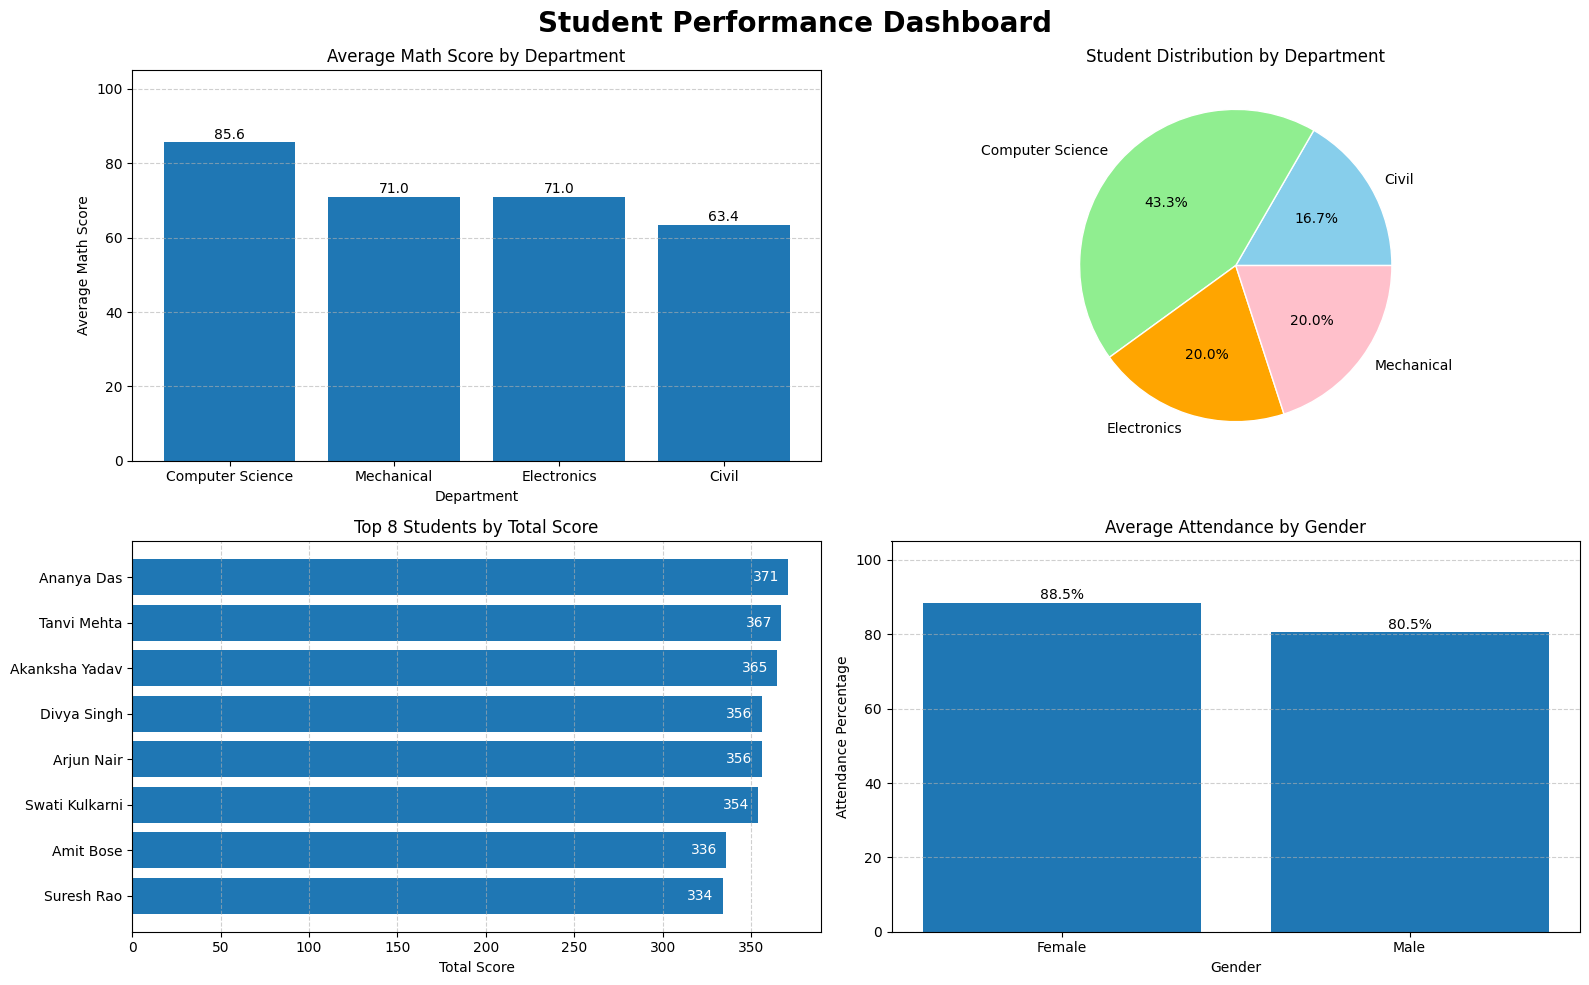

Dashboard saved successfully as 'student_dashboard.png'


In [67]:
# CREATE DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(16, 10))               # Creates a 2 × 2 grid of plots


# Panel 1: Avg Math by Department
ax1 = axes[0, 0]                     # top left chart

bars1 = ax1.bar(                     # create bars
    avg_math_df['department'],
    avg_math_df['avg_math']
)

ax1.set_title("Average Math Score by Department")
ax1.set_xlabel("Department")
ax1.set_ylabel("Average Math Score")
ax1.set_ylim(0, 105)                 # fixes Y-axis range (0 to 105)

ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,   # left position, center alignment,
        height + 1,                        # slightly above bar
        f'{height}',
        ha='center'
    )

# Panel 2: Student Count Pie Chart
ax2 = axes[0, 1]

colors = ['skyblue', 'lightgreen', 'orange', 'pink']

ax2.pie(
    student_count_df['student_count'],           # size of pie slices
    labels=student_count_df['department'],       # department names
    autopct='%1.1f%%',                           # shows percentage (like 25.0%)
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title("Student Distribution by Department")


# Panel 3: Top 8 Students Horizontal Bar
ax3 = axes[1, 0]

top_students_df = top_students_df.sort_values(
    by='total_score'
)

bars3 = ax3.barh(
    top_students_df['name'],
    top_students_df['total_score']
)

ax3.set_title("Top 8 Students by Total Score")
ax3.set_xlabel("Total Score")

ax3.grid(axis='x', linestyle='--', alpha=0.6)

# Score labels inside bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 20,
        bar.get_y() + bar.get_height()/2,
        f'{width}',
        va='center',
        color='white'
    )

# Panel 4: Gender Avg Attendance
ax4 = axes[1, 1]

bars4 = ax4.bar(
    attendance_df['gender'],
    attendance_df['avg_attendance']
)

ax4.set_title("Average Attendance by Gender")
ax4.set_xlabel("Gender")
ax4.set_ylabel("Attendance Percentage")
ax4.set_ylim(0, 105)

ax4.grid(axis='y', linestyle='--', alpha=0.6)

# Percentage labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center'
    )

# Dashboard Title and Layout
fig.suptitle(
    "Student Performance Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()              # automatically adjusts spacing so charts don’t overlap

# Save Dashboard
plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard saved successfully as 'student_dashboard.png'")

--END OF MINIPROJECT DAY-2--